# Violence Detection CGN Model Builder

## Dependencies Import

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install optuna optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 13.5 MB/s eta 0:00:00


In [2]:
import os
import math
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
import tensorflow as tf

In [4]:
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold

In [6]:
import optuna

## Config

In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Device: {gpus[0].name}")
  except RuntimeError as e:
    print(e)
else:
  print("Device: CPU")

Device: /physical_device:GPU:0


In [6]:
CLASSES = ['assault', 'fighting', 'shooting', 'robbery', 'normal_event']

ZIP_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset/violence_dataset.zip'
EXTRACT_PATH = '/content/dataset'
SAVE_DIR = '/content/drive/MyDrive/GCN_Models_Output'

RANDOM_SEED = 67
BATCH_SIZE = 64

TRIAL_EPOCH = 30
TRIAL_N = 20

TRAIN_EPOCH = 100

In [7]:
base_params = {'lr': 1e-4, 'beta_1': 0.90, 'hidden_gcn': 64, 'gcn_block_1': 1, 'gcn_block_2': 2, 'gcn_block_3': 2, 'num_tcn_blocks': 2, 'tcn_channel_ratio': 8, 'dropout': 0.5, 'weight_decay': 1e-5, 'warmup_epochs': 2}
max_params = {'lr': 1e-4, 'beta_1': 0.95, 'hidden_gcn': 128, 'gcn_block_1': 3, 'gcn_block_2': 3, 'gcn_block_3': 3, 'num_tcn_blocks': 3, 'tcn_channel_ratio': 8, 'dropout': 0.6, 'weight_decay': 1e-5, 'warmup_epochs': 8}

best_params = {'lr': 0.0002135537756670605, 'weight_decay': 0.00010148503880642396, 'beta_1': 0.8770503697589966, 'dropout': 0.22558600112493152, 'warmup_epochs': 2, 'hidden_gcn': 128, 'gcn_block_1': 1, 'gcn_block_2': 3, 'gcn_block_3': 2, 'num_tcn_blocks': 3, 'tcn_channel_ratio': 6}

In [8]:
keras_model_path = os.path.join(SAVE_DIR, "GNN_TCN_best.weights.h5")

tflite_model_backbone_path = os.path.join(SAVE_DIR, "GNN_TCN_backbone_best_int8.tflite")
tflite_model_head_path = os.path.join(SAVE_DIR, "GNN_TCN_head_best_int8.tflite")

hyperparameter_tuning_sqlite_path = os.path.join(SAVE_DIR, "hyperparameter_tuning.db")

In [9]:
if not os.path.exists(EXTRACT_PATH):
  print("Extracting Dataset...")
  with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
  print("Dataset has been extracted!")
else:
  print("Dataset has already been extracted previously")

Extracting Dataset...
Dataset has been extracted!


In [10]:
os.makedirs(SAVE_DIR, exist_ok=True)

## EDA

In [11]:
data_counts = {}
sample_shape = None

In [12]:
for cls in CLASSES:
  folder = os.path.join(EXTRACT_PATH, cls)
  if os.path.exists(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.npy')]
    data_counts[cls] = len(files)

    if len(files) > 0 and sample_shape is None:
      sample_path = os.path.join(folder, files[0])
      sample_data = np.load(sample_path)
      sample_shape = sample_data.shape
  else:
    data_counts[cls] = 0

In [13]:
print(f".npy Dimension Sample (C, T, V, M): {sample_shape}")
print(f"Sample Data Value Range: Min = {sample_data.min():.4f}, Max = {sample_data.max():.4f}")

.npy Dimension Sample (C, T, V, M): (3, 100, 17, 3)
Sample Data Value Range: Min = -517.6929, Max = 524.5895


In [14]:
print("=== Cek Axis 0 (apakah ini M=3 orang atau C=3 koordinat?) ===")
for i in range(sample_data.shape[0]):
  slice_i = sample_data[i]  # (100, 17, 3)
  print(f"  axis0[{i}]: mean={slice_i.mean():.3f}, std={slice_i.std():.3f}, "
        f"min={slice_i.min():.3f}, max={slice_i.max():.3f}")

=== Cek Axis 0 (apakah ini M=3 orang atau C=3 koordinat?) ===
  axis0[0]: mean=-53.095, std=183.656, min=-517.693, max=524.589
  axis0[1]: mean=-39.673, std=204.481, min=-454.205, max=426.877
  axis0[2]: mean=0.381, std=0.355, min=0.000, max=0.993


In [15]:
print("=== Cek Axis 3 (apakah ini C=3 koordinat atau M=3 orang?) ===")
for i in range(sample_data.shape[3]):
  slice_i = sample_data[:, :, :, i]  # (3, 100, 17)
  print(f"  axis3[{i}]: mean={slice_i.mean():.3f}, std={slice_i.std():.3f}, "
        f"min={slice_i.min():.3f}, max={slice_i.max():.3f}")

=== Cek Axis 3 (apakah ini C=3 koordinat atau M=3 orang?) ===
  axis3[0]: mean=25.408, std=130.451, min=-377.878, max=426.877
  axis3[1]: mean=-41.206, std=163.580, min=-502.290, max=246.927
  axis3[2]: mean=-76.589, std=167.183, min=-517.693, max=524.589


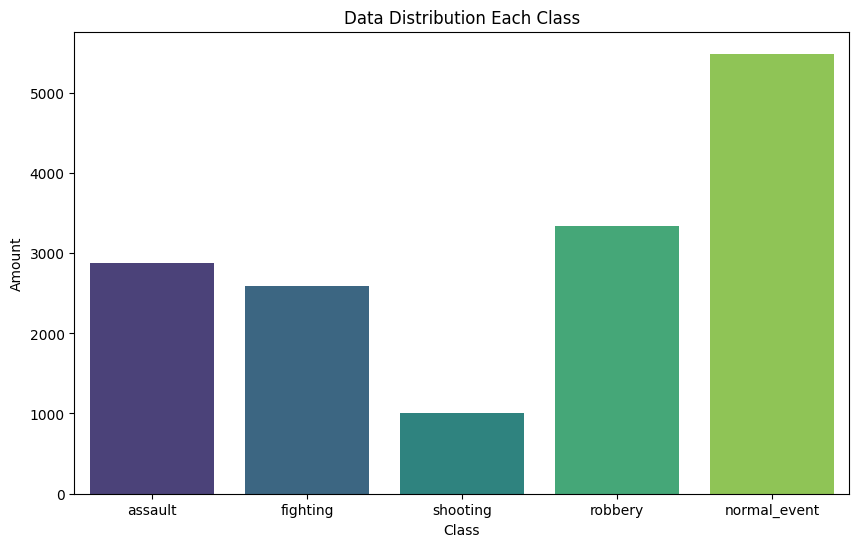

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(data_counts.keys()), y=list(data_counts.values()), hue=list(data_counts.keys()), palette="viridis", legend=False)
plt.title("Data Distribution Each Class")
plt.ylabel("Amount")
plt.xlabel("Class")
plt.show()

In [19]:
print("\nFile Amount Detail:")
for k, v in data_counts.items():
  print(f"- {k}: {v} files")


File Amount Detail:
- assault: 2871 files
- fighting: 2586 files
- shooting: 1002 files
- robbery: 3332 files
- normal_event: 5489 files


## Load Dataset

In [16]:
def preprocess_mtvc(data):
  return data.astype(np.float32)

In [17]:
def preprocess_ctvm(data):
  return np.transpose(data, (3, 1, 2, 0)).astype(np.float32)

In [18]:
# if your dataset is in MTVC format, then change the data_format value to 'MTVC'
def create_dataset_generator(file_paths, labels, data_format='CTVM'):
  if data_format == 'MTVC':
    preprocess_fn = preprocess_mtvc
  elif data_format == 'CTVM':
    preprocess_fn = preprocess_ctvm

  def generator():
    for path, label in zip(file_paths, labels):
      if isinstance(path, bytes):
        path = path.decode('utf-8')
      data = np.load(path).astype(np.float32)
      data = preprocess_fn(data)
      yield data, label
  return generator

In [19]:
all_files = []
all_labels = []

class_map = {cls_name: i for i, cls_name in enumerate(CLASSES)}

for cls in CLASSES:
    folder = os.path.join(EXTRACT_PATH, cls)
    if os.path.exists(folder):
        files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.npy')]
        all_files.extend(files)
        all_labels.extend([class_map[cls]] * len(files))

all_files = np.array(all_files)
all_labels = np.array(all_labels)

# Split data: 90% CV, 10% Test
X_cv, X_test, y_cv, y_test = train_test_split(all_files, all_labels, test_size=0.10, random_state=RANDOM_SEED, stratify=all_labels)

In [20]:
print(f"Total Dataset: {len(all_files)}")
print(f"CV Set: {len(X_cv)} (90%) | Test: {len(X_test)} (10%)")

Total Dataset: 15280
CV Set: 13752 (90%) | Test: 1528 (10%)


In [21]:
def build_tf_dataset(file_paths, labels, batch_size, shuffle=True):
    dataset = tf.data.Dataset.from_generator(
        create_dataset_generator(file_paths, labels),
        output_signature=(
            tf.TensorSpec(shape=(3, 100, 17, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(file_paths), 1000))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [22]:
test_dataset = build_tf_dataset(X_test.tolist(), y_test.tolist(), BATCH_SIZE, shuffle=False)

## Model Architecture

Model v3: Model GNN dibagi 2:
- GNN_BACKBONE: Untuk melakukan feature extraction per orang
- GNN_HEAD: Untuk melakukan klasifikasi dari gabungan hasil feature extraction 3 orang (maks. 3 orang)

In [23]:
raw_edges = [
  (0, 1), (0, 2), (1, 3), (2, 4),
  (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
  (11, 12), (5, 11), (6, 12),
  (11, 13), (13, 15), (12, 14), (14, 16)
]

In [24]:
def get_adjacency_matrix(num_joints=17):
  A = np.zeros((num_joints, num_joints))
  for i, j in raw_edges:
    A[i, j] = 1
    A[j, i] = 1
  A = A + np.eye(num_joints)
  D = np.diag(np.sum(A, axis=1) ** (-0.5))
  return np.dot(np.dot(D, A), D).astype(np.float32)

A_NORM = get_adjacency_matrix()

In [25]:
# GCN Spatial Graph Block
@keras.utils.register_keras_serializable()
class GraphConv(layers.Layer):
  def __init__(self, out_channels, num_vertices=17, adaptive=True, **kwargs):
    super().__init__(**kwargs)
    self.out_channels = out_channels
    self.num_vertices = num_vertices
    self.adaptive = adaptive

  def build(self, input_shape):
    in_channels = input_shape[-1]

    self.channel_proj = layers.Conv2D(
      self.out_channels, kernel_size=(1, 1),
      padding='same', use_bias=False
    )
    self.bn_proj = layers.BatchNormalization()

    self.graph_kernel = self.add_weight(
      name='graph_kernel',
      shape=(1, self.num_vertices, self.out_channels, 1),
      initializer=tf.keras.initializers.Constant(
        A_NORM[0:1, :].T.reshape(1, self.num_vertices, 1, 1)
        * np.ones((1, self.num_vertices, self.out_channels, 1))
      ),
      trainable=self.adaptive
    )
    self.bn_graph = layers.BatchNormalization()

    if in_channels != self.out_channels:
      self.downsample = keras.Sequential([
        layers.Conv2D(self.out_channels, (1, 1), use_bias=False),
        layers.BatchNormalization()
      ])
    else:
      self.downsample = None

    super().build(input_shape)

  def call(self, x):
    residual = self.downsample(x) if self.downsample is not None else x

    out = self.bn_proj(self.channel_proj(x))  # (B, T, V, C_out)

    out = tf.nn.depthwise_conv2d(
      out,
      filter=self.graph_kernel,
      strides=[1, 1, 1, 1],
      padding='SAME'
    )  # (B, T, V, C_out)

    out = self.bn_graph(out)
    return tf.nn.relu6(out + residual)

  def get_config(self):
    cfg = super().get_config()
    cfg.update({
      'out_channels': self.out_channels,
      'num_vertices': self.num_vertices,
      'adaptive': self.adaptive
    })
    return cfg

In [26]:
# Temporal Attention Mechanism
@keras.utils.register_keras_serializable()
class TCNBlock(layers.Layer):
  def __init__(self, filters, **kwargs):
    super().__init__(**kwargs)
    self.filters = filters

  def build(self, input_shape):
    f1 = self.filters // 3
    f2 = self.filters // 3
    f3 = self.filters - f1 - f2

    self.res_conv = layers.Conv2D(self.filters, (1, 1), padding='same', use_bias=False)
    self.res_bn   = layers.BatchNormalization()

    self.b1_conv = layers.Conv2D(f1, (3, 1), padding='same',
                                  dilation_rate=(1, 1), use_bias=False)
    self.b1_bn   = layers.BatchNormalization()

    self.b2_conv = layers.Conv2D(f2, (3, 1), padding='same',
                                  dilation_rate=(2, 1), use_bias=False)
    self.b2_bn   = layers.BatchNormalization()

    self.b3_conv = layers.Conv2D(f3, (3, 1), padding='same',
                                  dilation_rate=(4, 1), use_bias=False)
    self.b3_bn   = layers.BatchNormalization()

    self.concat     = layers.Concatenate(axis=-1)
    self.act_concat = layers.Activation('relu6')

    squeeze_ch = max(1, self.filters // 8)
    self._temporal_len = int(input_shape[1])  # static T, diketahui saat build

    self.ca_pool = layers.AveragePooling2D(pool_size=(self._temporal_len, 1),
                                            padding='valid')
    self.ca_conv1 = layers.Conv2D(squeeze_ch, (1, 1), padding='same', use_bias=False)
    self.ca_act1  = layers.Activation('relu6')
    self.ca_conv2 = layers.Conv2D(self.filters, (1, 1), padding='same', use_bias=False)
    self.ca_act2  = layers.Activation('sigmoid')
    self.ca_mul   = layers.Multiply()

    self.add       = layers.Add()
    self.final_act = layers.Activation('relu6')

    super().build(input_shape)

  def call(self, x):
    residual = self.res_bn(self.res_conv(x))

    b1 = self.b1_bn(self.b1_conv(x))
    b2 = self.b2_bn(self.b2_conv(x))
    b3 = self.b3_bn(self.b3_conv(x))

    out = self.act_concat(self.concat([b1, b2, b3]))  # (B, T, V, C)

    ca = self.ca_pool(out)                 # (B, 1, V, C)
    ca = self.ca_act1(self.ca_conv1(ca))   # (B, 1, V, C//8)
    ca = self.ca_act2(self.ca_conv2(ca))   # (B, 1, V, C)
    out = self.ca_mul([out, ca])           # broadcast (B,T,V,C)*(B,1,V,C)

    return self.final_act(self.add([out, residual]))

  def compute_output_shape(self, input_shape):
    return (input_shape[0], input_shape[1], input_shape[2], self.filters)

  def get_config(self):
    cfg = super().get_config()
    cfg.update({'filters': self.filters})
    return cfg

In [27]:
@keras.utils.register_keras_serializable()
class EarlyReshape(layers.Layer):
  def call(self, inputs):
    shape = tf.shape(inputs)
    B = shape[0]
    return tf.reshape(inputs, [B * 3, 100, 17, 3])

  def compute_output_shape(self, input_shape):
    return (None, 100, 17, 3)

@keras.utils.register_keras_serializable()
class LatePoolingTrain(layers.Layer):
  def __init__(self, hidden_dim, **kwargs):
    super().__init__(**kwargs)
    self.hidden_dim = hidden_dim

  def call(self, inputs):
    x = tf.reshape(inputs, [-1, 3, self.hidden_dim])
    return tf.reduce_max(x, axis=1)

  def compute_output_shape(self, input_shape):
    return (None, self.hidden_dim)

  def get_config(self):
    cfg = super().get_config()
    cfg.update({'hidden_dim': self.hidden_dim})
    return cfg

@keras.utils.register_keras_serializable()
class LatePoolingTPU(layers.Layer):
  def __init__(self, hidden_dim, **kwargs):
    super().__init__(**kwargs)
    self.hidden_dim = hidden_dim

  def call(self, inputs):
      # inputs: (3, hidden_dim)
    x = tf.reshape(inputs, [1, 3, self.hidden_dim])
    return tf.reduce_max(x, axis=1)  # (1, hidden_dim)

  def compute_output_shape(self, input_shape):
    return (1, self.hidden_dim)

  def get_config(self):
    cfg = super().get_config()
    cfg.update({'hidden_dim': self.hidden_dim})
    return cfg

In [28]:
def build_gnn_train_model(num_classes=5, hidden_gcn=64, gcn_block_1=1, gcn_block_2=2, gcn_block_3=2, num_tcn_blocks=2, tcn_channel_ratio=8, dropout_rate=0.5):
  M = 3; T = 100; V = 17; C = 3
  final_hidden_dim = hidden_gcn * tcn_channel_ratio

  inputs = keras.Input(shape=(M, T, V, C), name="input_tensor")
  x = EarlyReshape(name="early_reshape")(inputs)

  # --- SPATIAL GCN PROCESSING ---
  for i in range(gcn_block_1):
    x = GraphConv(hidden_gcn, V, adaptive=True, name=f"gcn_block1_{i}")(x)

  for i in range(gcn_block_2):
    x = GraphConv(hidden_gcn * 2, V, adaptive=True, name=f"gcn_block2_{i}")(x)

  for i in range(gcn_block_3):
    x = GraphConv(hidden_gcn * 4, V, adaptive=True, name=f"gcn_block3_{i}")(x)

  x = layers.AveragePooling2D(pool_size=(1, V), name="joint_pool")(x)

  # --- TEMPORAL CONVOLUTION (TCN) ---
  for i in range(num_tcn_blocks):
    stage_ratio = max(1, round(tcn_channel_ratio * (i + 1) / num_tcn_blocks))
    tcn_filters = hidden_gcn * stage_ratio

    x = TCNBlock(tcn_filters, name=f"tcn_{i+1}")(x)
    x = layers.MaxPooling2D(pool_size=(2, 1), name=f"tpool_{i+1}")(x)

  # Output shape: (Batch * M, final_hidden_dim)
  x = layers.GlobalAveragePooling2D(name="temporal_pooling")(x)

  # --- LATE POOLING ---
  x = LatePoolingTrain(hidden_dim=final_hidden_dim, name="late_pooling_train")(x)

  # --- KLASIFIKASI AKHIR ---
  x = layers.Dense(final_hidden_dim, activation='relu6')(x)
  x = layers.Dropout(dropout_rate, name="dropout")(x)

  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = keras.Model(inputs=inputs, outputs=outputs, name="GNN_TCN_TPU")
  return model

In [29]:
def build_gnn_backbone_model(hidden_gcn=64, gcn_block_1=1, gcn_block_2=2, gcn_block_3=2, num_tcn_blocks=2, tcn_channel_ratio=8):
  T, V, C = 100, 17, 3
  hidden_dim = hidden_gcn * tcn_channel_ratio

  inputs = keras.Input(batch_shape=(1, T, V, C), name="input_tensor")
  x = inputs

  for i in range(gcn_block_1):
    x = GraphConv(hidden_gcn, V, adaptive=True, name=f"gcn_s1_{i}")(x)
  for i in range(gcn_block_2):
    x = GraphConv(hidden_gcn * 2, V, adaptive=True, name=f"gcn_s2_{i}")(x)
  for i in range(gcn_block_3):
    x = GraphConv(hidden_gcn * 4, V, adaptive=True, name=f"gcn_s3_{i}")(x)

  x = layers.AveragePooling2D(pool_size=(1, V), name="joint_pool")(x)

  for i in range(num_tcn_blocks):
    stage_ratio = max(1, round(tcn_channel_ratio * (i + 1) / num_tcn_blocks))
    tcn_filters = hidden_gcn * stage_ratio

    x = TCNBlock(tcn_filters, name=f"tcn_{i+1}")(x)
    x = layers.MaxPooling2D(pool_size=(2, 1), name=f"tpool_{i+1}")(x)

  outputs = layers.GlobalAveragePooling2D(name="temporal_gap")(x)

  return keras.Model(inputs=inputs, outputs=outputs, name="GNN_Backbone_Edge")

In [30]:
def build_gnn_head_model(num_classes=5, hidden_gcn=64, tcn_channel_ratio=8):
  hidden_dim = hidden_gcn * tcn_channel_ratio

  inputs = keras.Input(shape=(hidden_dim,), name="pooled_features")

  x = layers.Dense(hidden_dim, activation='relu6', name="fc1")(inputs)
  outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

  return keras.Model(inputs=inputs, outputs=outputs, name="GNN_Head_Edge")

## Hyper Parameter Tuning

In [35]:
class WarmupCosineDecay(optimizers.schedules.LearningRateSchedule):
  def __init__(self, initial_lr, total_steps, warmup_steps, min_lr_ratio=0.01):
    super().__init__()
    self.initial_lr   = initial_lr
    self.total_steps  = total_steps
    self.warmup_steps = warmup_steps
    self.min_lr       = initial_lr * min_lr_ratio

  def __call__(self, step):
    step = tf.cast(step, tf.float32)
    warmup_lr = self.initial_lr * (step / self.warmup_steps)

    progress  = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
    progress  = tf.clip_by_value(progress, 0.0, 1.0)
    cosine_lr = self.min_lr + 0.5 * (self.initial_lr - self.min_lr) * (
      1.0 + tf.cos(math.pi * progress)
    )

    return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

  def get_config(self):
    return {
      'initial_lr': self.initial_lr,
      'total_steps': self.total_steps,
      'warmup_steps': self.warmup_steps,
      'min_lr_ratio': self.min_lr / self.initial_lr
    }

In [36]:
def objective(trial):
  print(f"\n--- Starting Trial {trial.number} ---")

  # Parameters
  lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
  weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
  beta_1 = trial.suggest_float("beta_1", 0.85, 0.95)

  dropout_rate = trial.suggest_float("dropout", 0.2, 0.6)
  warmup_epochs = trial.suggest_int("warmup_epochs", 2, 8)

  hidden_gcn = trial.suggest_categorical("hidden_gcn", [64, 128])
  gcn_block_1 = trial.suggest_categorical("gcn_block_1", [1, 2, 3])
  gcn_block_2 = trial.suggest_categorical("gcn_block_2", [1, 2, 3])
  gcn_block_3 = trial.suggest_categorical("gcn_block_3", [1, 2, 3])

  num_tcn_blocks = trial.suggest_int("num_tcn_blocks", 1, 3)
  tcn_channel_ratio = trial.suggest_categorical("tcn_channel_ratio", [4, 6, 8])

  print(f"Params: lr ({lr}), weight_decay ({weight_decay}), beta_1 ({beta_1}), dropout_rate ({dropout_rate}), warmup_epochs ({warmup_epochs}), hidden_gcn ({hidden_gcn}), gcn_block1 ({gcn_block_1}), gcn_block2 ({gcn_block_2}), gcn_block3 ({gcn_block_3}), num_tcn_blocks ({num_tcn_blocks}), tcn_channel_ratio ({tcn_channel_ratio})")

  keras.backend.clear_session()

  X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_cv, y_cv, test_size=0.2, random_state=RANDOM_SEED, stratify=y_cv
  )

  train_dataset_f = build_tf_dataset(X_train_f.tolist(), y_train_f.tolist(), BATCH_SIZE, shuffle=True)
  val_dataset_f = build_tf_dataset(X_val_f.tolist(), y_val_f.tolist(), BATCH_SIZE, shuffle=False)

  model = build_gnn_train_model(
    num_classes=len(CLASSES),
    hidden_gcn=hidden_gcn,
    gcn_block_1=gcn_block_1,
    gcn_block_2=gcn_block_2,
    gcn_block_3=gcn_block_3,
    num_tcn_blocks=num_tcn_blocks,
    tcn_channel_ratio=tcn_channel_ratio,
    dropout_rate=dropout_rate,
  )

  steps_per_epoch = math.ceil(len(X_train_f) / BATCH_SIZE)
  total_steps     = TRIAL_EPOCH * steps_per_epoch
  warmup_steps    = warmup_epochs * steps_per_epoch

  lr_schedule = WarmupCosineDecay(initial_lr=lr, total_steps=total_steps, warmup_steps=warmup_steps, min_lr_ratio=0.01)

  optimizer = optimizers.AdamW(learning_rate=lr_schedule, weight_decay=weight_decay, beta_1=beta_1)
  early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=14, restore_best_weights=True)
  pruning_callback = optuna.integration.TFKerasPruningCallback(trial, monitor='val_loss')

  model.compile(optimizer=optimizer, loss=losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

  history = model.fit(
    train_dataset_f,
    validation_data=val_dataset_f,
    epochs=TRIAL_EPOCH,
    callbacks=[early_stop, pruning_callback],
    verbose=0
  )

  val_loss, val_acc = model.evaluate(val_dataset_f, verbose=0)
  print(f"Trial {trial.number} finished - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

  return val_loss

In [37]:
sampler = optuna.samplers.TPESampler(multivariate=True, seed=RANDOM_SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10,n_warmup_steps=8,interval_steps=2)

/tmp/ipykernel_8908/1058771634.py:1: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(multivariate=True, seed=RANDOM_SEED)


In [38]:
study_gnn_tcn = optuna.create_study(
    study_name="ST-GCN-TCN_hpt_study",
    direction="minimize",
    storage=f"sqlite:///{hyperparameter_tuning_sqlite_path}",
    load_if_exists=True,
    sampler=sampler,
    pruner=pruner,
    )

[I 2026-07-07 12:03:15,170] Using an existing study with name 'ST-GCN-TCN_hpt_study' instead of creating a new one.


In [39]:
if best_params is None:
  study_gnn_tcn.optimize(objective, n_trials=TRIAL_N, gc_after_trial=True)
else:
  print('Skipping hyperparameter tuning')


--- Starting Trial 80 ---
Params: lr (0.0011850911017001013), weight_decay (0.00013780188296491102), beta_1 (0.8606746958076785), dropout_rate (0.26304869123514774), warmup_epochs (3), hidden_gcn (128), gcn_block1 (3), gcn_block2 (3), gcn_block3 (1), num_tcn_blocks (1), tcn_channel_ratio (8)


/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.tfkeras` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.tfkeras` instead.
  return _bootstrap._gcd_import(name[level:], package, level)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
[I 2026-07-07 12:18:04,074] Trial 80 pruned. Trial was pruned at epoch 8.



--- Starting Trial 81 ---
Params: lr (0.00012337681956810036), weight_decay (0.0007283382025663348), beta_1 (0.8563879193863752), dropout_rate (0.25703625724012685), warmup_epochs (6), hidden_gcn (128), gcn_block1 (1), gcn_block2 (3), gcn_block3 (1), num_tcn_blocks (3), tcn_channel_ratio (6)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
[I 2026-07-07 12:30:43,009] Trial 81 pruned. Trial was pruned at epoch 14.



--- Starting Trial 82 ---
Params: lr (0.00019818855989878298), weight_decay (0.0003737740808733525), beta_1 (0.8691516898221956), dropout_rate (0.22745559071261717), warmup_epochs (3), hidden_gcn (128), gcn_block1 (1), gcn_block2 (3), gcn_block3 (2), num_tcn_blocks (3), tcn_channel_ratio (6)


...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
[I 2026-07-07 18:03:39,637] Trial 97 pruned. Trial was pruned at epoch 10.



--- Starting Trial 98 ---
Params: lr (0.00023160602385894545), weight_decay (1.4416821263894827e-05), beta_1 (0.8571568701400571), dropout_rate (0.3556783543350329), warmup_epochs (2), hidden_gcn (128), gcn_block1 (1), gcn_block2 (3), gcn_block3 (3), num_tcn_blocks (3), tcn_channel_ratio (6)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
[I 2026-07-07 18:41:41,567] Trial 98 finished with value: 0.4126058518886566 and parameters: {'lr': 0.00023160602385894545, 'weight_decay': 1.4416821263894827e-05, 'beta_1': 0.8571568701400571, 'dropout': 0.3556783543350329, 'warmup_epochs': 2, 'hidden_gcn': 128, 'gcn_block_1': 1, 'gcn_block_2': 3, 'gcn_block_3': 3, 'num_tcn_blocks': 3, 'tcn_channel_ratio': 6}. Best is trial 83 with value: 0.3925882875919342.


Trial 98 finished - Val Loss: 0.4126, Val Acc: 0.8771

--- Starting Trial 99 ---
Params: lr (0.00045453731356311013), weight_decay (0.00011551401591187734), beta_1 (0.8964697097830416), dropout_rate (0.28731150920713133), warmup_epochs (4), hidden_gcn (128), gcn_block1 (2), gcn_block2 (1), gcn_block3 (2), num_tcn_blocks (2), tcn_channel_ratio (8)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
[I 2026-07-07 18:51:40,085] Trial 99 pruned. Trial was pruned at epoch 10.


In [40]:
if best_params is None:
  print("=== Best Params ===")
  print(study_gnn_tcn.best_params)

=== Best Params ===
{'lr': 0.0002135537756670605, 'weight_decay': 0.00010148503880642396, 'beta_1': 0.8770503697589966, 'dropout': 0.22558600112493152, 'warmup_epochs': 2, 'hidden_gcn': 128, 'gcn_block_1': 1, 'gcn_block_2': 3, 'gcn_block_3': 2, 'num_tcn_blocks': 3, 'tcn_channel_ratio': 6}


## Model Training

In [41]:
if best_params is None:
  best_params = study_gnn_tcn.best_params

In [31]:
keras.backend.clear_session()

In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Change this to continue training
latest_fold = 0
best_overall_val_loss = float('inf')

histories = []

In [44]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
  print(f"\n--- Fold {fold + 1} ---")

  if(fold < latest_fold):
    print(f"Skipping fold {fold + 1}")
    continue

  keras.backend.clear_session()

  X_train_f, X_val_f = X_cv[train_idx], X_cv[val_idx]
  y_train_f, y_val_f = y_cv[train_idx], y_cv[val_idx]

  train_dataset_f = build_tf_dataset(X_train_f.tolist(), y_train_f.tolist(), BATCH_SIZE, shuffle=True)
  val_dataset_f = build_tf_dataset(X_val_f.tolist(), y_val_f.tolist(), BATCH_SIZE, shuffle=False)

  steps_per_epoch = math.ceil(len(X_train_f) / BATCH_SIZE)
  total_steps     = TRAIN_EPOCH * steps_per_epoch
  warmup_steps    = best_params['warmup_epochs'] * steps_per_epoch

  lr_schedule = WarmupCosineDecay(initial_lr=best_params['lr'], total_steps=total_steps, warmup_steps=warmup_steps, min_lr_ratio=0.01)

  optimizer = optimizers.AdamW(learning_rate=lr_schedule, weight_decay=best_params['weight_decay'], beta_1=best_params['beta_1'])
  early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

  model = build_gnn_train_model(
    num_classes=len(CLASSES),
    hidden_gcn=best_params['hidden_gcn'],
    gcn_block_1=best_params['gcn_block_1'],
    gcn_block_2=best_params['gcn_block_2'],
    gcn_block_3=best_params['gcn_block_3'],
    num_tcn_blocks=best_params['num_tcn_blocks'],
    tcn_channel_ratio=best_params['tcn_channel_ratio'],
    dropout_rate=best_params['dropout']
  )


  model.compile(optimizer=optimizer, loss=losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

  history = model.fit(
    train_dataset_f,
    validation_data=val_dataset_f,
    epochs=TRAIN_EPOCH,
    callbacks=[early_stopping],
    verbose=1
  )

  val_loss, val_acc = model.evaluate(val_dataset_f, verbose=0)
  print(f"Fold {fold + 1} Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

  histories.append(history)

  if val_loss < best_overall_val_loss:
    best_overall_val_loss = val_loss
    model.save_weights(keras_model_path)
    print(f"*** New best model found and saved! (Val Loss: {val_loss:.4f}) ***")


--- Fold 1 ---
Epoch 1/100
    172/Unknown 109s 431ms/step - accuracy: 0.3918 - loss: 1.8710

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


172/172 ━━━━━━━━━━━━━━━━━━━━ 116s 475ms/step - accuracy: 0.4368 - loss: 1.5078 - val_accuracy: 0.4308 - val_loss: 1.4035
Epoch 2/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 346ms/step - accuracy: 0.5389 - loss: 1.1617 - val_accuracy: 0.5591 - val_loss: 1.0947
Epoch 3/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 346ms/step - accuracy: 0.6000 - loss: 1.0160 - val_accuracy: 0.6140 - val_loss: 0.9662
Epoch 4/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 345ms/step - accuracy: 0.6501 - loss: 0.8984 - val_accuracy: 0.6612 - val_loss: 0.8775
Epoch 5/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 346ms/step - accuracy: 0.6873 - loss: 0.8062 - val_accuracy: 0.6961 - val_loss: 0.8311
Epoch 6/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 346ms/step - accuracy: 0.7125 - loss: 0.7366 - val_accuracy: 0.6819 - val_loss: 0.8301
Epoch 7/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 346ms/step - accuracy: 0.7496 - loss: 0.6711 - val_accuracy: 0.7081 - val_loss: 0.7824
Epoch 8/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 60s 346ms/step - accuracy: 0.7682 - loss: 0.61

In [45]:
model.summary()

Model: "GNN_TCN_TPU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tensor (InputLayer)       │ (None, 3, 100, 17, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ early_reshape (EarlyReshape)    │ (None, 100, 17, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block1_0 (GraphConv)        │ (None, 100, 17, 128)   │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block2_0 (GraphConv)        │ (None, 100, 17, 256)   │        72,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block2_1 (GraphConv)        │ (None, 100, 17, 256)   │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block2_2 (GraphConv)        │ (None, 100, 17, 256)   │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block3_0 (GraphConv)        │ (None, 100, 17, 512)   │       276,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block3_1 (GraphConv)        │ (None, 100, 17, 512)   │       274,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ joint_pool (AveragePooling2D)   │ (None, 100, 1, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCNBlock)                │ (None, 100, 1, 256)    │       542,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_1 (MaxPooling2D)          │ (None, 50, 1, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_2 (TCNBlock)                │ (None, 50, 1, 512)     │       593,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_2 (MaxPooling2D)          │ (None, 25, 1, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_3 (TCNBlock)                │ (None, 25, 1, 768)     │     1,726,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_3 (MaxPooling2D)          │ (None, 12, 1, 768)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pooling                │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ late_pooling_train              │ (None, 768)            │             0 │
│ (LatePoolingTrain)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 768)            │       590,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         3,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,661,136 (48.30 MB)

 Trainable params: 4,215,173 (16.08 MB)

 Non-trainable params: 15,616 (61.00 KB)

 Optimizer params: 8,430,347 (32.16 MB)

## Train Result

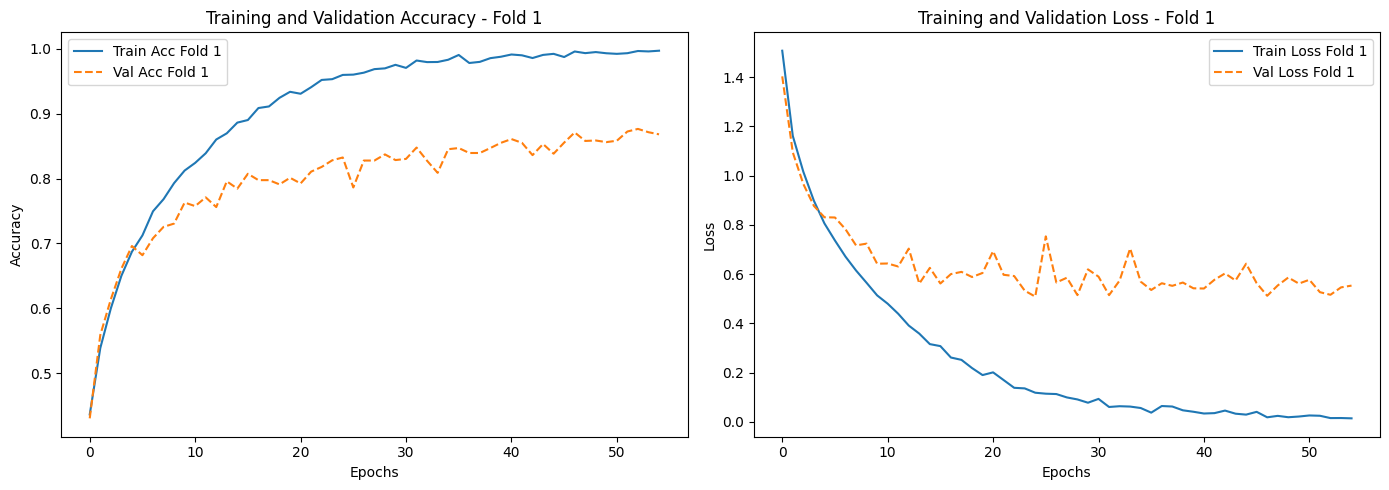

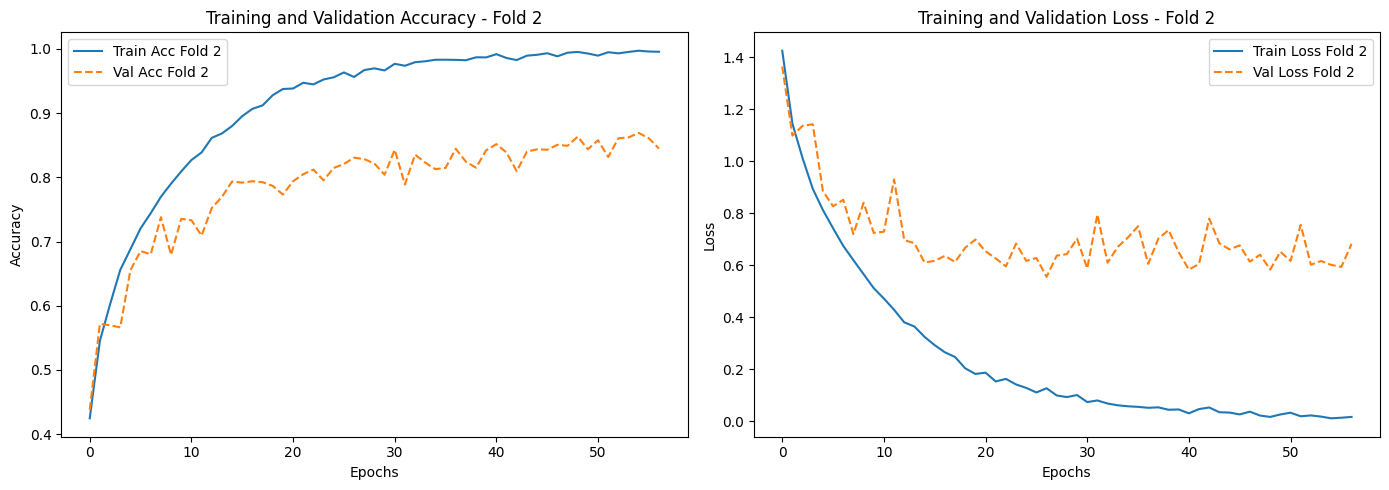

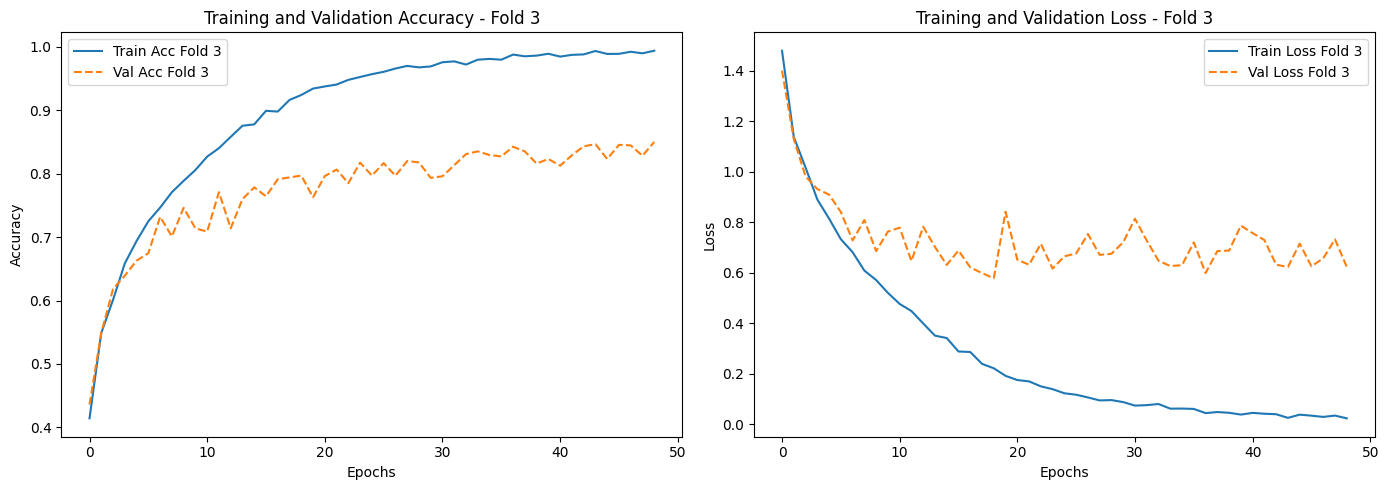

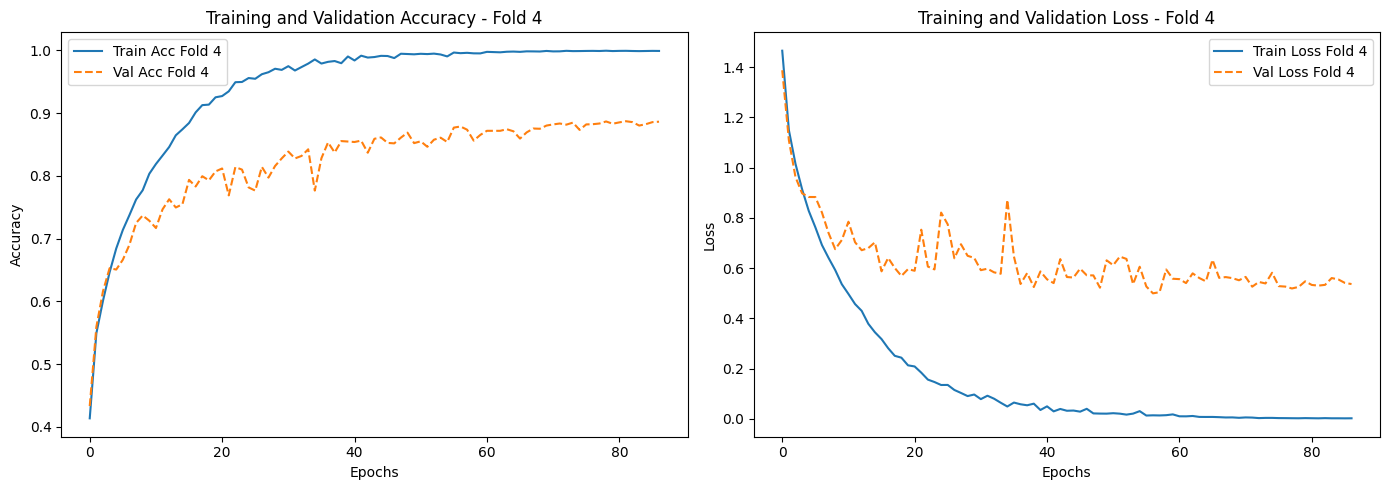

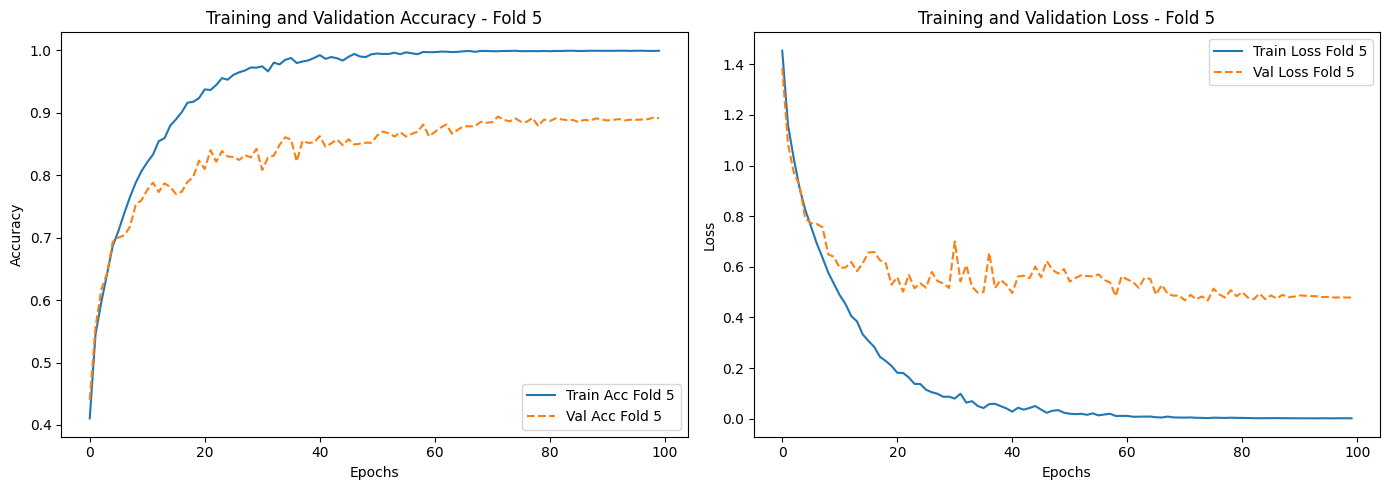

In [46]:
for i, hist in enumerate(histories):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label=f'Train Acc Fold {i+1}')
    plt.plot(hist.history['val_accuracy'], linestyle='--', label=f'Val Acc Fold {i+1}')
    plt.title(f'Training and Validation Accuracy - Fold {i+1}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label=f'Train Loss Fold {i+1}')
    plt.plot(hist.history['val_loss'], linestyle='--', label=f'Val Loss Fold {i+1}')
    plt.title(f'Training and Validation Loss - Fold {i+1}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

## Model Test

In [32]:
test_model = build_gnn_train_model(
    num_classes=len(CLASSES),
    hidden_gcn=best_params['hidden_gcn'],
    gcn_block_1=best_params['gcn_block_1'],
    gcn_block_2=best_params['gcn_block_2'],
    gcn_block_3=best_params['gcn_block_3'],
    num_tcn_blocks=best_params['num_tcn_blocks'],
    tcn_channel_ratio=best_params['tcn_channel_ratio'],
    dropout_rate=best_params['dropout']
)

dummy_input = tf.zeros((1, 3, 100, 17, 3))
test_model(dummy_input)

test_model.load_weights(keras_model_path)

test_model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

test_model.summary()

Model: "GNN_TCN_TPU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tensor (InputLayer)       │ (None, 3, 100, 17, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ early_reshape (EarlyReshape)    │ (None, 100, 17, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block1_0 (GraphConv)        │ (None, 100, 17, 128)   │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block2_0 (GraphConv)        │ (None, 100, 17, 256)   │        72,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block2_1 (GraphConv)        │ (None, 100, 17, 256)   │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block2_2 (GraphConv)        │ (None, 100, 17, 256)   │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block3_0 (GraphConv)        │ (None, 100, 17, 512)   │       276,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_block3_1 (GraphConv)        │ (None, 100, 17, 512)   │       274,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ joint_pool (AveragePooling2D)   │ (None, 100, 1, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCNBlock)                │ (None, 100, 1, 256)    │       542,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_1 (MaxPooling2D)          │ (None, 50, 1, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_2 (TCNBlock)                │ (None, 50, 1, 512)     │       593,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_2 (MaxPooling2D)          │ (None, 25, 1, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_3 (TCNBlock)                │ (None, 25, 1, 768)     │     1,726,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_3 (MaxPooling2D)          │ (None, 12, 1, 768)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pooling                │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ late_pooling_train              │ (None, 768)            │             0 │
│ (LatePoolingTrain)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 768)            │       590,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         3,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,230,789 (16.14 MB)

 Trainable params: 4,215,173 (16.08 MB)

 Non-trainable params: 15,616 (61.00 KB)

In [33]:
test_loss, test_acc = test_model.evaluate(test_dataset)

24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 822ms/step - accuracy: 0.9607 - loss: 0.1501


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [34]:
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc:.4f}")

Test Loss: 0.1501
Test Acc: 0.9607


In [35]:
y_pred_prob = test_model.predict(test_dataset)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_true_bin = label_binarize(y_true, classes=range(len(CLASSES)))

24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step


In [36]:
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


=== Classification Report ===
              precision    recall  f1-score   support

     assault     0.9516    0.9582    0.9549       287
    fighting     0.9651    0.9614    0.9632       259
    shooting     0.9457    0.8700    0.9062       100
     robbery     0.9459    0.9459    0.9459       333
normal_event     0.9748    0.9872    0.9810       549

    accuracy                         0.9607      1528
   macro avg     0.9566    0.9446    0.9503      1528
weighted avg     0.9606    0.9607    0.9605      1528



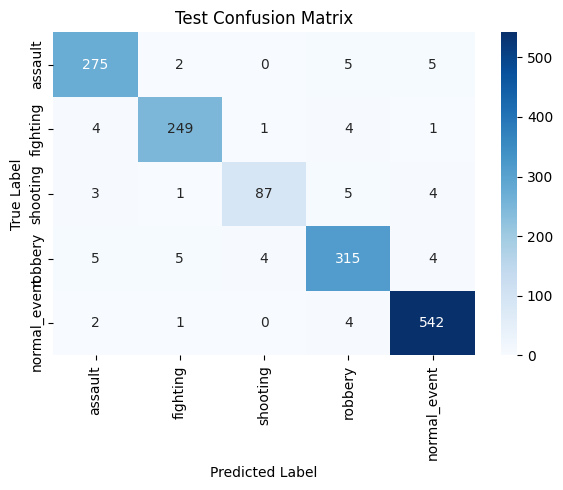

In [37]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## TFLite Conversion (Full Integer Quantization)

In [38]:
def representative_data_gen(num_samples=1000):
  count = 0

  for input_value, _ in test_dataset.unbatch().take(num_samples):
    data_mtvc = input_value.numpy()

    for m in range(3):
      person = data_mtvc[m]
      yield [person[np.newaxis, ...].astype(np.float32)]

    count += 1
    if count >= num_samples:
      break

In [39]:
def transfer_weights_to_edgetpu(train_model, backbone_model, head_model):
  train_weights = train_model.get_weights()
  n_backbone = len(backbone_model.get_weights())
  n_head = len(head_model.get_weights())

  assert n_backbone + n_head == len(train_weights), (
      f"Jumlah weight tidak cocok: backbone={n_backbone}, head={n_head}, "
      f"train={len(train_weights)}."
  )

  backbone_model.set_weights(train_weights[:n_backbone])
  head_model.set_weights(train_weights[n_backbone:])
  print(f"Transfer OK -> backbone: {n_backbone} tensor, head: {n_head} tensor")

In [40]:
backbone_model = build_gnn_backbone_model(
    hidden_gcn=best_params['hidden_gcn'],
    gcn_block_1=best_params['gcn_block_1'],
    gcn_block_2=best_params['gcn_block_2'],
    gcn_block_3=best_params['gcn_block_3'],
    num_tcn_blocks=best_params['num_tcn_blocks'],
    tcn_channel_ratio=best_params['tcn_channel_ratio'],
)

dummy_bb = tf.zeros((1, 100, 17, 3))
_ = backbone_model(dummy_bb)

backbone_model.summary()

Model: "GNN_Backbone_Edge"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tensor (InputLayer)       │ (1, 100, 17, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_s1_0 (GraphConv)            │ (1, 100, 17, 128)      │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_s2_0 (GraphConv)            │ (1, 100, 17, 256)      │        72,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_s2_1 (GraphConv)            │ (1, 100, 17, 256)      │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_s2_2 (GraphConv)            │ (1, 100, 17, 256)      │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_s3_0 (GraphConv)            │ (1, 100, 17, 512)      │       276,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gcn_s3_1 (GraphConv)            │ (1, 100, 17, 512)      │       274,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ joint_pool (AveragePooling2D)   │ (1, 100, 1, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCNBlock)                │ (1, 100, 1, 256)       │       542,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_1 (MaxPooling2D)          │ (1, 50, 1, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_2 (TCNBlock)                │ (1, 50, 1, 512)        │       593,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_2 (MaxPooling2D)          │ (1, 25, 1, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_3 (TCNBlock)                │ (1, 25, 1, 768)        │     1,726,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tpool_3 (MaxPooling2D)          │ (1, 12, 1, 768)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_gap                    │ (1, 768)               │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,636,352 (13.87 MB)

 Trainable params: 3,620,736 (13.81 MB)

 Non-trainable params: 15,616 (61.00 KB)

In [41]:
print(f"{'Layer name':30s} {'Class':20s} {'#Weights':10s} {'Built?'}")
print("-" * 75)
total = 0
for layer in backbone_model.layers:
    w = layer.get_weights()
    built = getattr(layer, 'built', 'N/A')
    print(f"{layer.name:30s} {layer.__class__.__name__:20s} {len(w):<10d} {built}")
    total += len(w)

print("-" * 75)
print(f"TOTAL: {total}")
print(f"\nbackbone_model.get_weights() total: {len(backbone_model.get_weights())}")


Layer name                     Class                #Weights   Built?
---------------------------------------------------------------------------
input_tensor                   InputLayer           0          True
gcn_s1_0                       GraphConv            15         True
gcn_s2_0                       GraphConv            15         True
gcn_s2_1                       GraphConv            10         True
gcn_s2_2                       GraphConv            10         True
gcn_s3_0                       GraphConv            15         True
gcn_s3_1                       GraphConv            10         True
joint_pool                     AveragePooling2D     0          True
tcn_1                          TCNBlock             22         True
tpool_1                        MaxPooling2D         0          True
tcn_2                          TCNBlock             22         True
tpool_2                        MaxPooling2D         0          True
tcn_3                          TCNBloc

In [42]:
head_model = build_gnn_head_model(
    num_classes=len(CLASSES),
    hidden_gcn=best_params['hidden_gcn'],
    tcn_channel_ratio=best_params['tcn_channel_ratio']
)

head_model.summary()

Model: "GNN_Head_Edge"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pooled_features (InputLayer)    │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 768)            │       590,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         3,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,437 (2.27 MB)

 Trainable params: 594,437 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
transfer_weights_to_edgetpu(test_model, backbone_model, head_model)

Transfer OK -> backbone: 141 tensor, head: 4 tensor


In [44]:
backbone_converter = tf.lite.TFLiteConverter.from_keras_model(backbone_model)
backbone_converter.optimizations = [tf.lite.Optimize.DEFAULT]
backbone_converter.representative_dataset = representative_data_gen
backbone_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
backbone_converter.inference_input_type  = tf.int8
backbone_converter.inference_output_type = tf.int8

In [45]:
print("Konversi model backbone ke TFLite...")
try:
  tflite_quant_model_backbone = backbone_converter.convert()
  with open(tflite_model_backbone_path, 'wb') as f:
    f.write(tflite_quant_model_backbone)
  print(f"TFLite model successfully saved to {tflite_model_backbone_path}")

  model_size_kb = os.path.getsize(tflite_model_backbone_path) / 1024
  print(f"Quantized Model Size: {model_size_kb:.2f} KB")
except Exception as e:
  print(f"Failed to convert model to TFLite: {e}")

Konversi model backbone ke TFLite...
Saved artifact at '/tmp/tmpgujzeb38'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 100, 17, 3), dtype=tf.float32, name='input_tensor')
Output Type:
  TensorSpec(shape=(1, 768), dtype=tf.float32, name=None)
Captures:
  137276420193744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740052240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740052048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740051856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740052816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740050896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740052432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740052624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740051664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740053776: TensorSpec(shape=(), dtype=tf.resou

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model successfully saved to /content/drive/MyDrive/GCN_Models_Output/GNN_TCN_backbone_best_int8.tflite
Quantized Model Size: 3807.20 KB


In [46]:
head_converter = tf.lite.TFLiteConverter.from_keras_model(head_model)

In [47]:
print("Konversi model head ke TFLite...")
try:
  tflite_quant_model_head = head_converter.convert()
  with open(tflite_model_head_path, 'wb') as f:
      f.write(tflite_quant_model_head)
  print(f"TFLite model successfully saved to {tflite_model_head_path}")

  model_size_kb = os.path.getsize(tflite_model_head_path) / 1024
  print(f"Quantized Model Size: {model_size_kb:.2f} KB")
except Exception as e:
    print(f"Failed to convert model to TFLite: {e}")

Konversi model head ke TFLite...
Saved artifact at '/tmp/tmpupkq5b7x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 768), dtype=tf.float32, name='pooled_features')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137273740066640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740064912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273740056080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137273731955024: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model successfully saved to /content/drive/MyDrive/GCN_Models_Output/GNN_TCN_head_best_int8.tflite
Quantized Model Size: 2323.73 KB


## Compile with Edge TPU Compiler

reference: [coral.ai Web-based Edge TPU Compiler](https://colab.research.google.com/github/google-coral/tutorials/blob/master/compile_for_edgetpu.ipynb)

In [48]:
! curl https://packages.cloud.google.com/apt/doc/apt-key.gpg | sudo apt-key add -

! echo "deb https://packages.cloud.google.com/apt coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list

! sudo apt-get update

! sudo apt-get install edgetpu-compiler

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1022  100  1022    0     0  12769      0 --:--:-- --:--:-- --:--:-- 12775
OK
deb https://packages.cloud.google.com/apt coral-edgetpu-stable main
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://packages.cloud.google.com/apt coral-edgetpu-stable InRelease [1,423 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net

In [49]:
!edgetpu_compiler {tflite_model_backbone_path}

Edge TPU Compiler version 16.0.384591198
Started a compilation timeout timer of 180 seconds.

Model compiled successfully in 1548 ms.

Input model: /content/drive/MyDrive/GCN_Models_Output/GNN_TCN_backbone_best_int8.tflite
Input size: 3.72MiB
Output model: GNN_TCN_backbone_best_int8_edgetpu.tflite
Output size: 4.38MiB
On-chip memory used for caching model parameters: 4.10MiB
On-chip memory remaining for caching model parameters: 2.06MiB
Off-chip memory used for streaming uncached model parameters: 0.00B
Number of Edge TPU subgraphs: 1
Total number of operations: 62
Operation log: GNN_TCN_backbone_best_int8_edgetpu.log
See the operation log file for individual operation details.
Compilation child process completed within timeout period.
Compilation succeeded! 


In [50]:
base_path, ext = os.path.splitext(tflite_model_backbone_path)
edgetpu_dest_path = f"{base_path}_edgetpu{ext}"
edgetpu_log_dest_path = f"{base_path}_edgetpu.log"

edgetpu_source_filename = f"{os.path.basename(base_path)}_edgetpu{ext}"
edgetpu_log_filename = f"{os.path.basename(base_path)}_edgetpu.log"

edgetpu_source_path = os.path.join('/content', edgetpu_source_filename)
edgetpu_log_path = os.path.join('/content', edgetpu_log_filename)

if os.path.exists(edgetpu_source_path):
  shutil.move(edgetpu_source_path, edgetpu_dest_path)
  print(f"Edge TPU Model has been moved to: {edgetpu_dest_path}")
else:
  print(f"Moving Failed. File source not found: {edgetpu_source_path}")

if os.path.exists(edgetpu_log_path):
  shutil.move(edgetpu_log_path, edgetpu_log_dest_path)
  print(f"Edge TPU Model has been moved to: {edgetpu_log_dest_path}")
else:
  print(f"Moving Failed. File source not found: {edgetpu_log_path}")

Edge TPU Model has been moved to: /content/drive/MyDrive/GCN_Models_Output/GNN_TCN_backbone_best_int8_edgetpu.tflite
Edge TPU Model has been moved to: /content/drive/MyDrive/GCN_Models_Output/GNN_TCN_backbone_best_int8_edgetpu.log


# Converted Model Test

In [51]:
def quantize(data_float32, scale, zero_point, dtype=np.int8):
  if scale > 0:
    q = np.round(data_float32 / scale + zero_point)
    q = np.clip(q, np.iinfo(dtype).min, np.iinfo(dtype).max)
    return q.astype(dtype)
  return data_float32.astype(dtype)

In [52]:
def dequantize(data_int, scale, zero_point):
  if scale > 0:
    return (data_int.astype(np.float32) - zero_point) * scale
  return data_int.astype(np.float32)

In [53]:
def load_interpreter(model_path):
  interp = tf.lite.Interpreter(model_path=model_path)
  interp.allocate_tensors()
  return interp

In [54]:
def print_model_details(interp, name):
  inp = interp.get_input_details()[0]
  out = interp.get_output_details()[0]
  print(f"=== {name} ===")
  print(f"  Input  shape : {inp['shape']}")
  print(f"  Input  dtype : {inp['dtype']}")
  print(f"  Input  quant : scale={inp['quantization'][0]:.6f}, zp={inp['quantization'][1]}")
  print(f"  Output shape : {out['shape']}")
  print(f"  Output dtype : {out['dtype']}")
  print(f"  Output quant : scale={out['quantization'][0]:.6f}, zp={out['quantization'][1]}")

In [55]:
def run_inference_one_sample(data_mtvc, backbone_interp, head_interp):
  bb_inp  = backbone_interp.get_input_details()[0]
  bb_out  = backbone_interp.get_output_details()[0]
  hd_inp  = head_interp.get_input_details()[0]
  hd_out  = head_interp.get_output_details()[0]

  M = data_mtvc.shape[0]

  feature_vectors = []
  for m in range(M):
    person = data_mtvc[m]
    person_input = person[np.newaxis, ...].astype(np.float32)

    person_q = quantize(
      person_input,
      scale=bb_inp['quantization'][0],
      zero_point=bb_inp['quantization'][1],
      dtype=bb_inp['dtype']
    )

    backbone_interp.set_tensor(bb_inp['index'], person_q)
    backbone_interp.invoke()

    feat_q = backbone_interp.get_tensor(bb_out['index'])
    feat = dequantize(feat_q, bb_out['quantization'][0], bb_out['quantization'][1])
    feature_vectors.append(feat)

  features_stacked = np.stack(feature_vectors, axis=0)
  pooled = np.max(features_stacked, axis=0)

  head_q = quantize(
    pooled,
    scale=hd_inp['quantization'][0],
    zero_point=hd_inp['quantization'][1],
    dtype=hd_inp['dtype']
  )

  head_interp.set_tensor(hd_inp['index'], head_q)
  head_interp.invoke()

  out_q  = head_interp.get_tensor(hd_out['index'])
  probs  = dequantize(out_q, hd_out['quantization'][0], hd_out['quantization'][1])

  return probs[0], pooled[0]

In [56]:
backbone_interp = load_interpreter(tflite_model_backbone_path)
head_interp     = load_interpreter(tflite_model_head_path)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [57]:
print_model_details(backbone_interp, "BACKBONE (Edge TPU / CPU)")

=== BACKBONE (Edge TPU / CPU) ===
  Input  shape : [  1 100  17   3]
  Input  dtype : <class 'numpy.int8'>
  Input  quant : scale=5.005877, zp=-1
  Output shape : [  1 768]
  Output dtype : <class 'numpy.int8'>
  Output quant : scale=0.023529, zp=-128


In [58]:
print_model_details(head_interp, "HEAD (CPU)")

=== HEAD (CPU) ===
  Input  shape : [  1 768]
  Input  dtype : <class 'numpy.float32'>
  Input  quant : scale=0.000000, zp=0
  Output shape : [1 5]
  Output dtype : <class 'numpy.float32'>
  Output quant : scale=0.000000, zp=0


## Dataset Sample Test

In [59]:
def test_with_dataset(test_dataset, backbone_interp, head_interp, CLASSES, num_samples=5):
  correct = 0
  total   = 0

  for x_sample, y_sample in test_dataset.unbatch().take(num_samples):
    # x_sample: Tensor (M=3, T=100, V=17, C=3)
    # y_sample: Tensor () — integer label
    data_mtvc  = x_sample.numpy().astype(np.float32)
    true_label = int(y_sample.numpy())

    probs, _ = run_inference_one_sample(data_mtvc, backbone_interp, head_interp)
    pred_label = int(np.argmax(probs))

    status  = "✓" if pred_label == true_label else "✗"
    correct += int(pred_label == true_label)
    total   += 1

    print(f"\n  [{status}] True: {CLASSES[true_label]:15s} | "
          f"Pred: {CLASSES[pred_label]:15s}")
    print(f"       Probs: {np.round(probs, 4)}")

  print(f"\n  Accuracy ({total} sample): {correct}/{total} = {correct/total*100:.1f}%")

In [60]:
test_with_dataset(test_dataset, backbone_interp, head_interp, CLASSES, num_samples=5)


  [✓] True: assault         | Pred: assault        
       Probs: [1. 0. 0. 0. 0.]

  [✓] True: normal_event    | Pred: normal_event   
       Probs: [6.000e-04 0.000e+00 1.000e-04 0.000e+00 9.993e-01]

  [✓] True: assault         | Pred: assault        
       Probs: [1. 0. 0. 0. 0.]

  [✓] True: shooting        | Pred: shooting       
       Probs: [1.00e-04 1.00e-04 9.99e-01 8.00e-04 0.00e+00]

  [✓] True: normal_event    | Pred: normal_event   
       Probs: [0. 0. 0. 0. 1.]

  Accuracy (5 sample): 5/5 = 100.0%


# Dataset_test Test

In [61]:
def evaluate_full_test_set(test_dataset, backbone_interp, head_interp, CLASSES):
  y_true_all, y_pred_all = [], []

  for x_batch, y_batch in test_dataset:
    for i in range(x_batch.shape[0]):
      data_mtvc  = x_batch[i].numpy().astype(np.float32)
      true_label = int(y_batch[i].numpy())

      probs, _ = run_inference_one_sample(data_mtvc, backbone_interp, head_interp)
      pred_label = int(np.argmax(probs))

      y_true_all.append(true_label)
      y_pred_all.append(pred_label)

  y_true_all = np.array(y_true_all)
  y_pred_all = np.array(y_pred_all)
  accuracy   = np.mean(y_true_all == y_pred_all)

  print(f"\n  Total sample : {len(y_true_all)}")
  print(f"  Akurasi      : {accuracy*100:.2f}%")

  print("\n  Per-class accuracy:")
  for i, cls in enumerate(CLASSES):
    mask     = y_true_all == i
    n        = mask.sum()
    n_correct = (y_pred_all[mask] == i).sum()
    print(f"    [{i}] {cls:20s}: {n_correct:3d}/{n:3d} = {n_correct/max(n,1)*100:.1f}%")

  return y_true_all, y_pred_all

In [62]:
y_true, y_pred = evaluate_full_test_set(test_dataset, backbone_interp, head_interp, CLASSES)


  Total sample : 1528
  Akurasi      : 96.47%

  Per-class accuracy:
    [0] assault             : 275/287 = 95.8%
    [1] fighting            : 253/259 = 97.7%
    [2] shooting            :  89/100 = 89.0%
    [3] robbery             : 318/333 = 95.5%
    [4] normal_event        : 539/549 = 98.2%


In [63]:
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


=== Classification Report ===
              precision    recall  f1-score   support

     assault     0.9549    0.9582    0.9565       287
    fighting     0.9583    0.9768    0.9675       259
    shooting     0.9570    0.8900    0.9223       100
     robbery     0.9493    0.9550    0.9521       333
normal_event     0.9836    0.9818    0.9827       549

    accuracy                         0.9647      1528
   macro avg     0.9606    0.9524    0.9562      1528
weighted avg     0.9647    0.9647    0.9646      1528



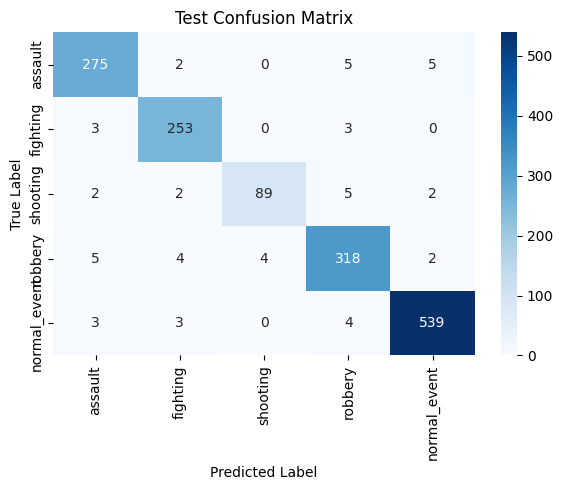

In [64]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Sanity Test

In [65]:
def test_with_synthetic_data(backbone_interp, head_interp, CLASSES):
  """
  Backbone input shape: (1, T=100, V=17, C=3)
  - C=0 : X coordinate (pixel, ~[-300, 300])
  - C=1 : Y coordinate (pixel, ~[-300, 300])
  - C=2 : confidence score ([0, 1])
  """
  T, V = 100, 17

  test_cases = {
    "All zero (empty padding)": np.zeros((3, T, V, 3), dtype=np.float32),
    "Noise pixel coordinate (-300..300)": np.concatenate([
        np.random.uniform(-300, 300, (3, T, V, 2)).astype(np.float32),
        np.random.uniform(0, 1, (3, T, V, 1)).astype(np.float32)
    ], axis=-1),
    "Normalized coordinate (0,1)": np.random.uniform(0, 1, (3, T, V, 3)).astype(np.float32),
    "Only one person, two are zero": np.concatenate([
        np.concatenate([
            np.random.uniform(-200, 200, (1, T, V, 2)).astype(np.float32),
            np.random.uniform(0.5, 1, (1, T, V, 1)).astype(np.float32)
        ], axis=-1),
        np.zeros((2, T, V, 3), dtype=np.float32)
    ], axis=0),
  }

  for name, data_mtvc in test_cases.items():
    probs, feat = run_inference_one_sample(data_mtvc, backbone_interp, head_interp)
    pred_label  = int(np.argmax(probs))
    entropy     = -np.sum(probs * np.log(np.clip(probs, 1e-9, 1)))

    print(f"\n  Input: {name}")
    print(f"    Pred      : {CLASSES[pred_label]} ({pred_label})")
    print(f"    Probs     : {np.round(probs, 4)}")
    print(f"    Entropy   : {entropy:.4f}  "
          f"({'uniform/uncertain' if entropy > 1.0 else 'confident'})")
    print(f"    Feat range: [{feat.min():.4f}, {feat.max():.4f}]")

In [66]:
test_with_synthetic_data(backbone_interp, head_interp, CLASSES)


  Input: All zero (empty padding)
    Pred      : normal_event (4)
    Probs     : [1.610e-02 1.000e-04 1.577e-01 1.936e-01 6.324e-01]
    Entropy   : 0.9668  (confident)
    Feat range: [0.0000, 4.5412]

  Input: Noise pixel coordinate (-300..300)
    Pred      : assault (0)
    Probs     : [0.9817 0.     0.     0.0038 0.0145]
    Entropy   : 0.1008  (confident)
    Feat range: [0.0000, 5.9294]

  Input: Normalized coordinate (0,1)
    Pred      : normal_event (4)
    Probs     : [1.610e-02 1.000e-04 1.577e-01 1.936e-01 6.324e-01]
    Entropy   : 0.9668  (confident)
    Feat range: [0.0000, 4.5412]

  Input: Only one person, two are zero
    Pred      : assault (0)
    Probs     : [0.8773 0.0035 0.0025 0.0455 0.0712]
    Entropy   : 0.4783  (confident)
    Feat range: [0.0000, 5.6471]


## Additionaly convert YOLO Model to Edge TPU TFLite as well

In [ ]:
# !pip install ultralytics

In [ ]:
# from ultralytics import YOLO

In [ ]:
# !yolo export model=yolov8n-pose.pt format=edgetpu imgsz=512 int8=True

In [ ]:
# !yolo export model=yolov8s-pose.pt format=edgetpu imgsz=512 int8=True

In [ ]:
# !yolo export model=yolo11n-pose.pt format=edgetpu imgsz=512 int8=True

In [ ]:
# !yolo export model=yolo26n-pose.pt format=edgetpu imgsz=512 int8=True

In [ ]:
# edgetpu_yolo_model_path = "/content/yolov8n-pose_saved_model/yolov8n-pose_full_integer_quant_edgetpu.tflite"
# edgetpu_yolo_model_paths = [
#     "/content/yolov8n-pose_saved_model/yolov8n-pose_full_integer_quant_edgetpu.tflite",
#     "/content/yolov8s-pose_saved_model/yolov8s-pose_full_integer_quant_edgetpu.tflite",
#     "/content/yolo11n-pose_saved_model/yolo11n-pose_full_integer_quant_edgetpu.tflite",
#     "/content/yolo26n-pose_saved_model/yolo26n-pose_full_integer_quant_edgetpu.tflite",
#     ]

In [ ]:
# for edgetpu_yolo_model_path in edgetpu_yolo_model_paths:
#   yolo_log_path = edgetpu_yolo_model_path.replace('.tflite', '.log')
#   yolo_quant_path = edgetpu_yolo_model_path.replace('_edgetpu.tflite', '.tflite')

#   files_to_move = [edgetpu_yolo_model_path, yolo_log_path, yolo_quant_path]

#   for file_path in files_to_move:
#       if os.path.exists(file_path):
#           dest_path = os.path.join(SAVE_DIR, os.path.basename(file_path))
#           shutil.move(file_path, dest_path)
#           print(f"File berhasil dipindahkan ke: {dest_path}")
#       else:
#           print(f"Gagal memindahkan. File sumber tidak ditemukan: {file_path}")